# MODEL TRAINING

In [1]:
TRAIN_PATH = "train_set_selected.csv"
TARGET_COL = None
RANDOM_STATE = 42
N_FOLDS = 5
BASELINE_MODEL_PATH = "model_baseline.pkl"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

pd.set_option("display.max_columns", None)

train_df = pd.read_csv(TRAIN_PATH)
print(f"Training set dimuat: {train_df.shape[0]} baris, {train_df.shape[1]} kolom")

if TARGET_COL is None:
    candidate_names = ["label", "Label", "class", "Class", "type", "Type",
                        "target", "Target", "phishing", "Phishing", "y", "Result", "result"]
    found = [c for c in candidate_names if c in train_df.columns]
    if found:
        TARGET_COL = found[0]
        print(f"Kolom target terdeteksi otomatis: '{TARGET_COL}'")

assert TARGET_COL is not None and TARGET_COL in train_df.columns, \
    "TARGET_COL belum valid. Isi manual di cell konfigurasi."

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

print(f"\nJumlah fitur: {X_train.shape[1]}")
print(f"Distribusi kelas pada training set:")
print(y_train.value_counts(normalize=True).round(4))


Training set dimuat: 41120 baris, 34 kolom
Kolom target terdeteksi otomatis: 'phishing'

Jumlah fitur: 33
Distribusi kelas pada training set:
phishing
0.0    0.6509
1.0    0.3491
Name: proportion, dtype: float64


In [3]:
baseline_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
baseline_model.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [4]:
train_accuracy = baseline_model.score(X_train, y_train)

In [5]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

model_for_cv = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

cv_results = cross_validate(
    model_for_cv, X_train, y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True,
    n_jobs=-1
)

print(f"Hasil {N_FOLDS}-Fold Cross Validation — Model Baseline (parameter default):\n")
cv_summary = []
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    train_scores = cv_results[f"train_{metric}"]
    val_scores = cv_results[f"test_{metric}"]
    cv_summary.append({
        "Metric": metric.upper(),
        "Train Mean": round(train_scores.mean(), 4),
        "Train Std": round(train_scores.std(), 4),
        "Validation Mean": round(val_scores.mean(), 4),
        "Validation Std": round(val_scores.std(), 4),
        "Gap (Train - Val)": round(train_scores.mean() - val_scores.mean(), 4),
    })

cv_summary_df = pd.DataFrame(cv_summary)
display(cv_summary_df)

Hasil 5-Fold Cross Validation — Model Baseline (parameter default):



,Metric,Train Mean,Train Std,Validation Mean,Validation Std,Gap (Train - Val)
0,ACCURACY,0.9849,0.0004,0.9381,0.0020,0.0469
1,PRECISION,0.9899,0.0005,0.9097,0.0033,0.0802
2,RECALL,0.9667,0.0014,0.9133,0.0029,0.0534
3,F1,0.9781,0.0006,0.9115,0.0029,0.0667
4,ROC_AUC,0.9981,0.0001,0.9771,0.0013,0.0209


In [6]:
GAP_WARNING_THRESHOLD = 0.05

overfit_flags = cv_summary_df[cv_summary_df["Gap (Train - Val)"] > GAP_WARNING_THRESHOLD]

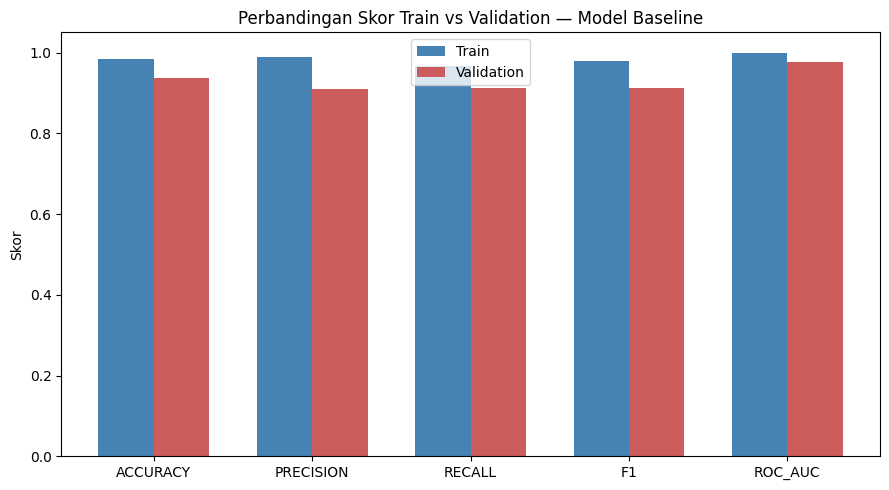

In [7]:
# visualisasi train score vs validation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(cv_summary_df))
width = 0.35

ax.bar(x - width/2, cv_summary_df["Train Mean"], width, label="Train", color="steelblue")
ax.bar(x + width/2, cv_summary_df["Validation Mean"], width, label="Validation", color="indianred")

ax.set_xticks(x)
ax.set_xticklabels(cv_summary_df["Metric"])
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Skor Train vs Validation — Model Baseline")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


Top 15 fitur paling berpengaruh pada model baseline:


,0
directory_length,0.158343
file_length,0.083031
length_url,0.079883
qty_asterisk_directory,0.072758
qty_hyphen_file,0.069481
qty_hyphen_directory,0.059947
qty_slash_url,0.050214
qty_percent_directory,0.048417
qty_at_directory,0.043854
qty_vowels_domain,0.042943


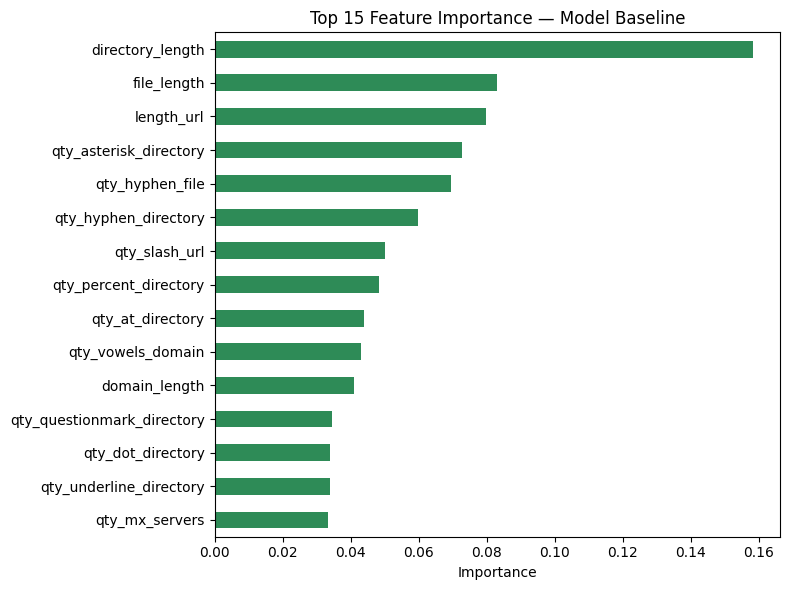

In [8]:
# Feature Importance Model Baseline
importance_series = pd.Series(
    baseline_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("Top 15 fitur paling berpengaruh pada model baseline:")
display(importance_series.head(15))

plt.figure(figsize=(8, 6))
importance_series.head(15).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 15 Feature Importance — Model Baseline")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [9]:
joblib.dump(baseline_model, BASELINE_MODEL_PATH)

['model_baseline.pkl']